# Harris Corner Detection
0. Input image: We want to compute 𝐻 at each pixel
1. Apply Gaussian filter to the image:

    a) Gaussian filter g() with width
2. Compute image derivatives (optionally, blur first). For example, a Sobel derivative filter 𝐼𝑥,𝐼𝑦
3. Compute $𝐼_𝑥^2 = 𝐼_𝑥 ∘ 𝐼x, 𝐼_y^2 = 𝐼_y ∘ 𝐼_𝑦, 𝐼_𝑥 ∘ 𝐼_𝑦$
4. Apply Gaussian filter to these
5. Compute 𝐻 components as squares/products of derivatives
6. Compute cornerness

    a) $𝐶 = det(H − \alpha(trace(H))^2$

    b) $C = 𝑔(𝐼_𝑥)$
7. Threshold (T) on 𝐶 to pick high cornerness: if C > T, C unchanged, if C ≤ T, C = 0
8. Non-maximal suppression to pick peaks

In [2]:
import cv2
import numpy as np
import os
import sys
import math
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [3]:
# image_fp = os.path.expanduser("~/data/Images/24-10-05 Saturn-480p.jpg")
image_fp = os.path.expanduser("~/data/Images/train-window-small.jpg")

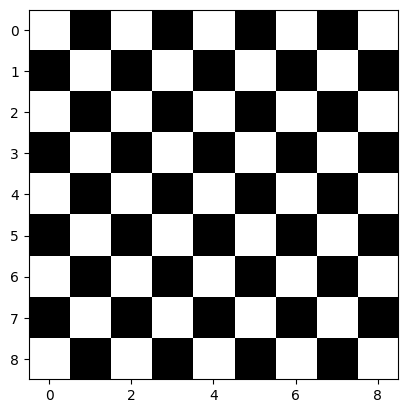

In [4]:
def display_image(
    im: cv2.Mat,
    title: str = None,
    show_ticks: bool = True,
    range: tuple[int, int] = (0, 255),
    corners: list[tuple[int, int]] = None
) -> None:
    if not isinstance(im, np.ndarray):
        im = np.array(im).astype(np.float32)
    if im is None:
        print("Error: Image is None")
        return
    
    im = (im - range[0]) / (range[1] - range[0]) * 255
    im = np.clip(im, 0, 255).astype(np.uint8)

    img_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    if title is not None:
        plt.title(title)
    if not show_ticks:
        plt.xticks([])
        plt.yticks([])
    if corners is not None:
        for x, y in corners:
            plt.plot(x, y, 'ro', markersize=3)
    plt.show()


def generate_checker(size: int) -> np.ndarray:
    checkerboard = np.zeros((size, size), dtype=np.uint8)
    for y in range(size):
        for x in range(size):
            if y % 2 == 0:
                if x % 2 == 0:
                    checkerboard[y, x] = 255
            else:
                if x % 2 == 1:
                    checkerboard[y, x] = 255
    return checkerboard

display_image(generate_checker(9))

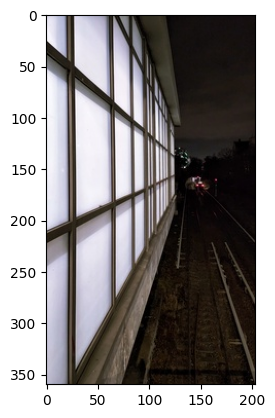

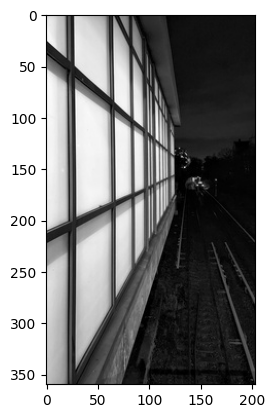

In [5]:
image = cv2.imread(image_fp)
image_bw = cv2.imread(image_fp, cv2.IMREAD_GRAYSCALE)
display_image(image)
display_image(image_bw)

In [6]:
def sobel_x() -> list[list[int]]:
    return [
        [-1/8, 0, 1/8],
        [-2/8, 0, 2/8],
        [-1/8, 0, 1/8],
    ]

def sobel_y() -> list[list[int]]:
    return [
        [1/8, 2/8, 1/8],
        [0, 0, 0],
        [-1/8, -2/8, -1/8],
    ]

def gaussian_3x3() -> list[list[int]]:
    return [
        [1/16, 2/16, 1/16],
        [2/16, 4/16, 2/16],
        [1/16, 2/16, 1/16],
    ]

Points after / before thresholding: 2273 / 73080
Points after NMS: 78


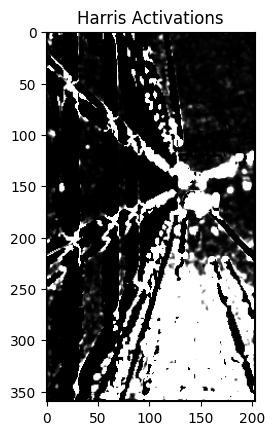

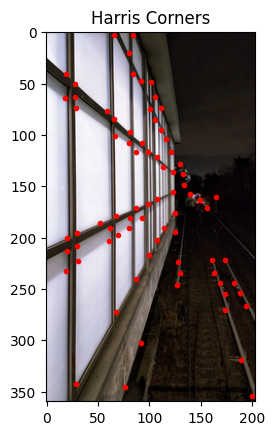

In [11]:
def apply_kernel_over_patch(
    im_arr: list[list[int]],
    im_width: int,
    im_height: int,
    kernel: list[list[int]],
    kernel_size: int,
) -> list[list[int]]:
    ret_arr = [[0 for _ in range(im_width)] for _ in range(im_height)]
    # Using "BorderIgnore" method
    hk = kernel_size//2
    for y in range(hk, im_height-hk):
        for x in range(hk, im_width-hk):
            v = 0
            for ky in range(kernel_size):
                for kx in range(kernel_size):
                    v += im_arr[y+ky-hk][x+kx-hk] * kernel[ky][kx]
            ret_arr[y][x] = v
    return ret_arr

def element_wise_product(
    im_arr1: list[list[int]],
    im_arr2: list[list[int]],
    im_width: int,
    im_height: int
) -> list[list[int]]:
    ret_arr = [[0 for _ in range(im_width)] for _ in range(im_height)]
    for y in range(im_height):
        for x in range(im_width):
            ret_arr[y][x] = im_arr1[y][x] * im_arr2[y][x]
    return ret_arr

def compute_H_activation(
    gIxx: list[list[int]],
    gIxy: list[list[int]],
    gIyy: list[list[int]],
    im_width: int,
    im_height: int,
    w: int,
    alpha: float,
) -> list[list[int]]:
    ret_arr = [[0. for _ in range(im_width)] for _ in range(im_height)]
    # H = [ [sum(Ixx), sum(Ixy)],
    #       [sum(Ixy), sum(Iyy)] ]
    # Uses "BorderIgnore method"
    hw = w//2
    for y in range(hw, im_height-hw):
        for x in range(hw, im_width-hw):
            s_Ixx, s_Ixy, s_Iyy = 0., 0., 0.
            for wy in range(w):
                for wx in range(w):
                    s_Ixx += gIxx[y+wy-hw][x+wx-hw]
                    s_Ixy += gIxy[y+wy-hw][x+wx-hw]
                    s_Iyy += gIyy[y+wy-hw][x+wx-hw]
            H = [[s_Ixx, s_Ixy],
                 [s_Ixy, s_Iyy]]
            # det(H) = ad - bc = s_Ixx*s_Iyy - s_Ixy*s_Ixy
            det_H = s_Ixx*s_Iyy - s_Ixy*s_Ixy
            # trace(H) = sum of diagonal = s_Ixx + s_Iyy
            trace_H = s_Ixx + s_Iyy
            # C = det(H) - alpha * trace(H)^2
            C = det_H - alpha * trace_H**2
            ret_arr[y][x] = C
    return ret_arr


def harris_corner_detector(
    im_arr: list[list[int]],
    im_width: int,
    im_height: int,
    alpha: float=0.04,
    debug: bool=True
):
    Ix = apply_kernel_over_patch(im_arr, im_width, im_height, sobel_x(), 3)
    Iy = apply_kernel_over_patch(im_arr, im_width, im_height, sobel_y(), 3)

    Ixx = element_wise_product(Ix, Ix, im_width, im_height)
    Ixy = element_wise_product(Ix, Iy, im_width, im_height)
    Iyy = element_wise_product(Iy, Iy, im_width, im_height)

    gIxx = apply_kernel_over_patch(Ixx, im_width, im_height, gaussian_3x3(), 3)
    gIxy = apply_kernel_over_patch(Ixy, im_width, im_height, gaussian_3x3(), 3)
    gIyy = apply_kernel_over_patch(Iyy, im_width, im_height, gaussian_3x3(), 3)

    harris = compute_H_activation(gIxx, gIxy, gIyy, im_width, im_height, 3, alpha)

    if debug:
        display_image(Ix, "Sobel X", (-128, 128))
        display_image(Iy, "Sobel Y", (-128, 128))
        display_image(Ixx, "Sobel XX", (-(128**2), 128**2))
        display_image(Ixy, "Sobel XY", (-(128**2), 128**2))
        display_image(Iyy, "Sobel YY", (-(128**2), 128**2))
        display_image(gIxx, "g(Sobel XX)", (-(128**2), 128**2))
        display_image(gIxy, "g(Sobel XY)", (-(128**2), 128**2))
        display_image(gIyy, "g(Sobel YY)", (-(128**2), 128**2))

        harris_np = np.array(harris)
        display_image(harris, "Harris", (harris_np.min(), harris_np.max()))
    return harris

def pick_harris_corners(
    harris: list[list[int]],
    im_width: int,
    im_height: int,
    threshold: float=0.0,
    nms: bool=True,
    nms_dist: float=10.0
) -> list[tuple[int, int]]:
    # Threshold
    pts = []  # (x, y, v)
    for y in range(im_height):
        for x in range(im_width):
            if harris[y][x] > threshold:
                pts.append((x, y, harris[y][x]))
    print(f"Points after / before thresholding: {len(pts)} / {im_width*im_height}")
    pts = sorted(pts, key=lambda pt: pt[2], reverse=True)
    pts = [(x, y) for x, y, v in pts]
    if not nms:
        return pts
    # NMS
    selected_pts = []
    for pt_x, pt_y in pts:
        too_close = False
        for cpt_x, cpt_y in selected_pts:
            if math.sqrt((pt_x-cpt_x)**2 + (pt_y-cpt_y)**2) <= nms_dist:
                too_close = True
                break
        if not too_close:
            selected_pts.append((pt_x, pt_y))
    print(f"Points after NMS: {len(selected_pts)}")
    return selected_pts

harris_im = harris_corner_detector(image_bw.tolist(), image_bw.shape[1], image_bw.shape[0], debug=False)
harris_pts = pick_harris_corners(harris_im, image_bw.shape[1], image_bw.shape[0], threshold=1e6, nms=True)

harris_im_np = np.array(harris_im)
display_image(harris_im_np, "Harris Activations", (harris_im_np.min(), harris_im_np.max()))
display_image(image, "Harris Corners", corners=harris_pts)